In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px

In [7]:
#支持中文
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [8]:
df=pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-12\AMZN_2006-01-01_to_2018-01-01.csv")

In [9]:
df.head(3)

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN


In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   object 
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 165.2+ KB


,Open,High,Low,Close,Volume
count,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03
mean,299.335310,302.371163,296.037695,299.376231,5.931712e+06
std,280.120547,281.826442,277.927134,279.980161,5.122034e+06
min,26.090000,26.300000,25.760000,26.070000,9.864350e+05
25%,81.175000,82.580000,79.725000,81.090000,3.137037e+06
50%,205.330000,208.000000,202.100000,205.440000,4.724100e+06
75%,375.570000,379.155000,373.000000,375.140000,7.135246e+06
max,1204.880000,1213.410000,1191.150000,1195.830000,1.044046e+08


In [11]:
# 准备数据
sequence_length = 20  # 序列长度：使用前19天预测第20天
X = []
y = []

# 获取收盘价数据并转换为numpy数组
prices = df['Close'].values

# 创建序列数据
for i in range(len(prices) - sequence_length):
    X.append(prices[i:(i + sequence_length - 1)])  # 前19天数据作为特征
    y.append(prices[i + sequence_length - 1])      # 第20天数据作为标签

# 转换为numpy数组
X = np.array(X)
y = np.array(y)

# 数据归一化
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# 转换为PyTorch张量，并调整维度以适应RNN/LSTM输入要求 (batch_size, seq_length, input_size)
X_train = torch.FloatTensor(X_train).unsqueeze(-1)
X_test = torch.FloatTensor(X_test).unsqueeze(-1)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

轮次 [10/100], 损失: 0.0002
轮次 [20/100], 损失: 0.0001
轮次 [30/100], 损失: 0.0001
轮次 [40/100], 损失: 0.0001
轮次 [50/100], 损失: 0.0001
轮次 [60/100], 损失: 0.0001
轮次 [70/100], 损失: 0.0001
轮次 [80/100], 损失: 0.0000
轮次 [90/100], 损失: 0.0000
轮次 [100/100], 损失: 0.0000


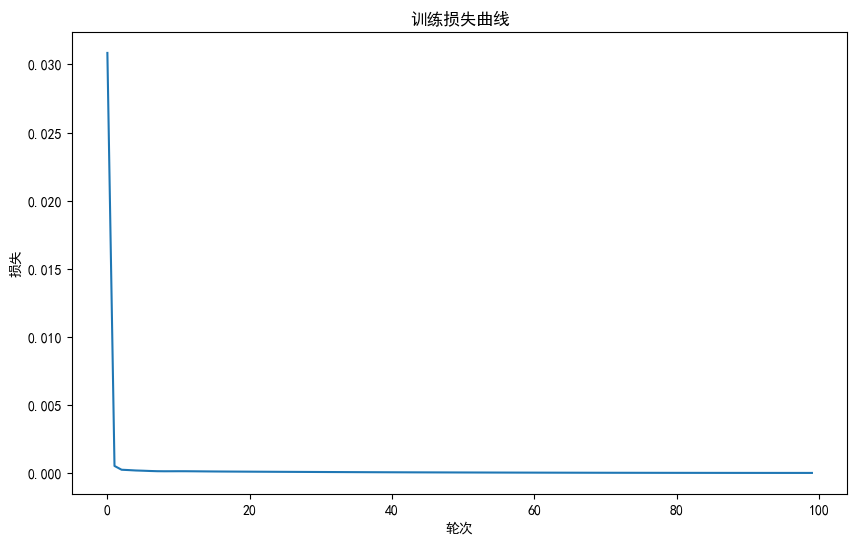


测试集MSE: 143.20
测试集R2分数: 0.9982


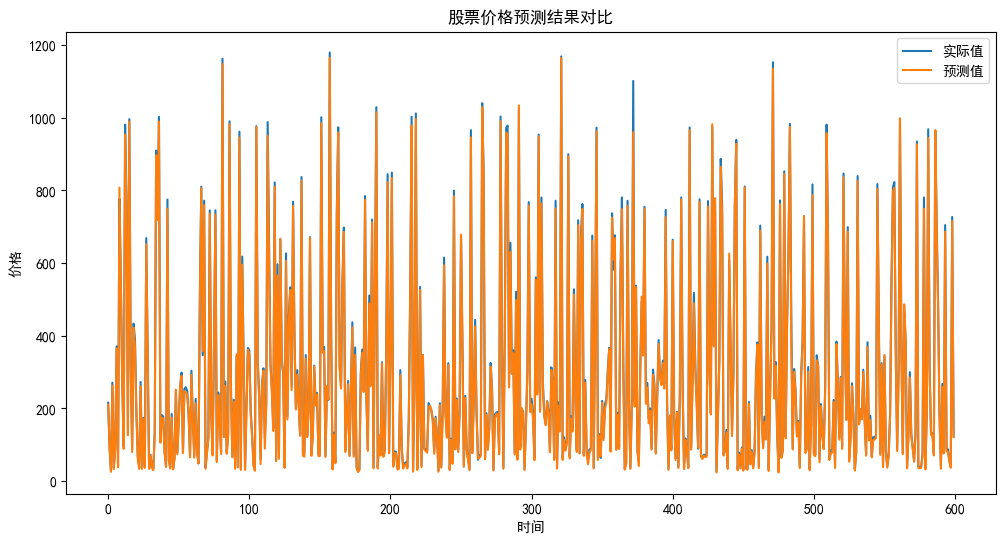

In [12]:
# 定义LSTM模型
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # LSTM前向传播
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # 只使用最后一个时间步的输出
        return out

# 设置模型参数
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 100
batch_size = 32
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # 批量训练
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]
        
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / (len(X_train) // batch_size)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'轮次 [{epoch+1}/{num_epochs}], 损失: {avg_loss:.4f}')

# 绘制训练损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('训练损失曲线')
plt.xlabel('轮次')
plt.ylabel('损失')
plt.show()

# 模型评估
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    test_loss = criterion(y_pred, y_test)
    
    # 反归一化预测结果
    y_pred = scaler.inverse_transform(y_pred.numpy())
    y_test = scaler.inverse_transform(y_test.numpy())
    
    # 计算评估指标
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
print(f'\n测试集MSE: {mse:.2f}')
print(f'测试集R2分数: {r2:.4f}')

# 绘制预测结果对比图
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='实际值')
plt.plot(y_pred, label='预测值')
plt.title('股票价格预测结果对比')
plt.xlabel('时间')
plt.ylabel('价格')
plt.legend()
plt.show()